# EDA – Sephora Reviews Sentiment Analysis
Exploratory data analysis for sentiment model training.

In [17]:
import warnings
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 4)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
TARGET = 'LABEL-rating-category'
ID_LIKE = ['product_id', 'brand_id', 'product_name', 'brand_name', 'variation_desc']

In [18]:
df = pd.read_csv('data/processed/reviews.csv', low_memory=False)
print(f'Shape: {df.shape}')
df.head(2)

Shape: (1092063, 32)


,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_id,brand_name,...,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,LABEL-rating-category,review_text_length,has_exclamation,caps_ratio
0,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,unknown,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,7055.0,NUDESTIX,...,0.0,['Clean at Sephora'],Skincare,Cleansers,unknown,0.0,1.0,455,1,0.039773
1,I bought this lip mask after reading the revie...,Disappointed,unknown,unknown,unknown,unknown,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,6125.0,LANEIGE,...,1.0,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,unknown,3.0,0.0,162,0,0.015152


## 1. Feature Overview

In [19]:
bool_cols = [
    c for c in df.columns
    if df[c].dropna().isin([0, 1]).all() and c != TARGET
]
num_cols = [
    c for c in df.select_dtypes(include='number').columns
    if c not in bool_cols and c != TARGET
]
text_cols = [
    c for c in df.select_dtypes(include='object').columns
    if df[c].dropna().str.len().mean() > 50 and c not in ID_LIKE
]
cat_cols = [
    c for c in df.select_dtypes(include='object').columns
    if c not in text_cols and c not in ID_LIKE
]

print(f'Total columns:   {df.shape[1]}')
print(f'  Text:          {len(text_cols)} -> {text_cols}')
print(f'  Categorical:   {len(cat_cols)} -> {cat_cols}')
print(f'  Boolean (0/1): {len(bool_cols)} -> {bool_cols}')
print(f'  Numerical:     {len(num_cols)} -> {num_cols}')
print(f'  Target:        {TARGET} (categorical, 2 classes: 0=negative, 1=positive)')

Total columns:   32
  Text:          3 -> ['review_text', 'ingredients', 'highlights']
  Categorical:   11 -> ['review_title', 'skin_tone', 'eye_color', 'skin_type', 'hair_color', 'size', 'variation_type', 'variation_value', 'primary_category', 'secondary_category', 'tertiary_category']
  Boolean (0/1): 6 -> ['limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'has_exclamation']
  Numerical:     8 -> ['brand_id', 'loves_count', 'rating', 'reviews', 'price_usd', 'child_count', 'review_text_length', 'caps_ratio']
  Target:        LABEL-rating-category (categorical, 2 classes: 0=negative, 1=positive)


**11 categorical** features (skin attributes, product categories), **8 numerical** (prices, counts, engineered), **6 binary** flags.
Target is **categorical** (2 classes: negative / positive), stored as float64.

## 2. Class Distribution (Target)

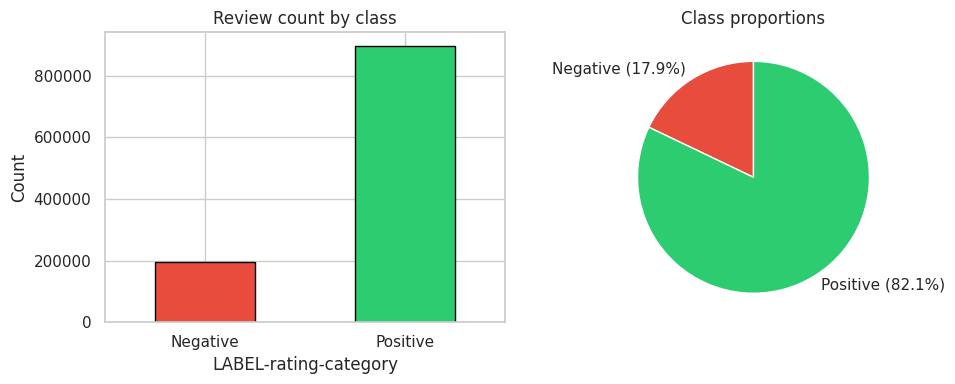

In [20]:
COLORS = {0.0: '#e74c3c', 1.0: '#2ecc71'}
CLASS_LABELS = {0.0: 'Negative', 1.0: 'Positive'}

counts = df[TARGET].value_counts().sort_index()
pct    = (counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts.plot(kind='bar', ax=axes[0],
            color=[COLORS[k] for k in counts.index], edgecolor='black')
axes[0].set_title('Review count by class')
axes[0].set_xticklabels([CLASS_LABELS[k] for k in counts.index], rotation=0)
axes[0].set_ylabel('Count')

pct.plot(kind='pie', ax=axes[1],
         labels=[f'{CLASS_LABELS[k]} ({v:.1f}%)' for k, v in zip(pct.index, pct)],
         colors=[COLORS[k] for k in pct.index], autopct='', startangle=90)
axes[1].set_title('Class proportions')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

## 3. Missing Values

In [ ]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

if len(missing) == 0:
    print('No missing values — preprocessing already handled all NaNs.')
else:
    miss_df = pd.DataFrame({'missing_count': missing, 'missing_pct_%': missing_pct})
    display(miss_df)
    missing_pct.plot(kind='barh', figsize=(10, 6), color='steelblue')
    plt.xlabel('% missing values')
    plt.title('Missing values by column')
    plt.tight_layout()
    plt.show()

**Target has no missing values.**

| Group | Columns | Strategy |
|---|---|---|
| ~99% missing | `variation_desc`, `sale_price_usd`, `value_price_usd`, `price_vs_value_ratio` | Drop columns |
| 58% missing (numerical) | `child_min_price`, `child_max_price` | Drop columns (redundant with `price_usd`) |
| 10–21% missing (categorical) | `skin_tone`, `eye_color`, `hair_color`, `skin_type` | Fill with `'unknown'` |
| Text with missing | `review_title` (28%), `highlights` (10%), `ingredients` (2%) | Fill with `''` |
| `review_text` (0.1%) | Primary feature — rows unusable without it | Drop rows |
| 398 rows | Missing all product-level fields | Drop rows (caught by `dropna(subset=['product_id'])`) |

**Numerical imputation strategies (not needed here):**
- **Median** — fast, robust to outliers; suitable for low missingness (<20%)
- **KNN** — uses neighbouring rows; more accurate but expensive at scale

Numerical columns with high missingness were dropped (redundant with `price_usd`), so imputation was not needed.

In [ ]:
corr_cols = num_cols + bool_cols + [TARGET]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation matrix (Pearson)')
plt.tight_layout()
plt.show()

## 5. Correlations

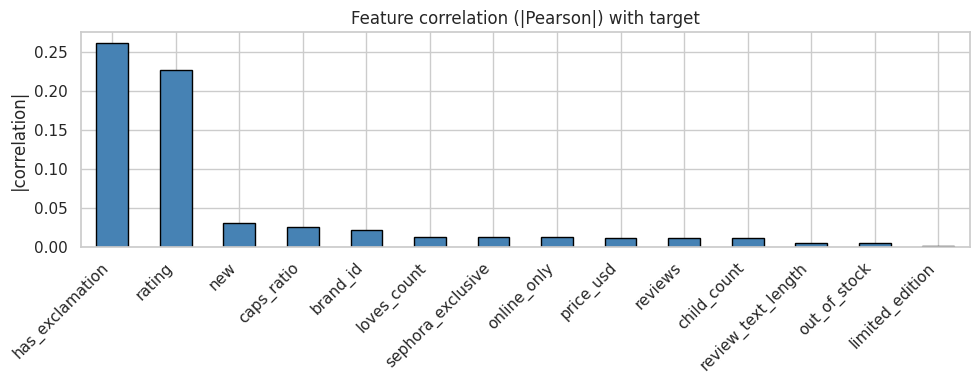

In [23]:
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
target_corr.plot(kind='bar', figsize=(10, 4), color='steelblue', edgecolor='black')
plt.title('Feature correlation (|Pearson|) with target')
plt.ylabel('|correlation|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Numerical Features – Distributions by Class

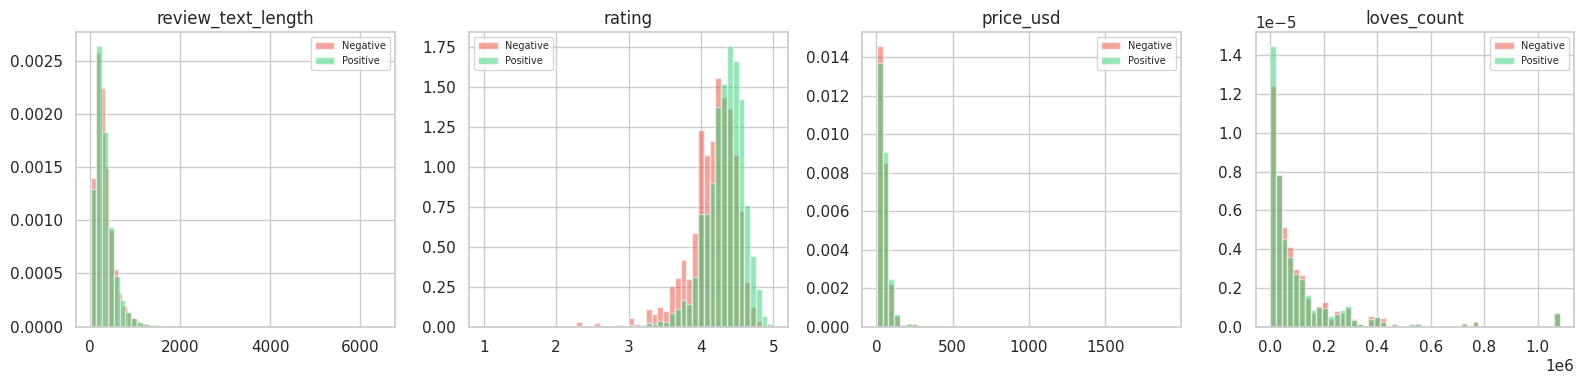

In [24]:
key_num = ['review_text_length', 'rating', 'price_usd', 'loves_count']
fig, axes = plt.subplots(1, len(key_num), figsize=(16, 4))
for ax, col in zip(axes, key_num):
    for cls, grp in df.groupby(TARGET):
        ax.hist(grp[col].dropna(), bins=50, alpha=0.5,
                label=CLASS_LABELS[cls], color=COLORS[cls], density=True)
    ax.set_title(col)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 7. Categorical Features

In [25]:
display(pd.DataFrame({
    'unique_values': {c: df[c].nunique() for c in cat_cols},
    'missing_pct_%': {c: round(df[c].isnull().mean() * 100, 1) for c in cat_cols}
}))

,unique_values,missing_pct_%
review_title,363916,28.3
skin_tone,15,0.0
eye_color,7,0.0
skin_type,5,0.0
hair_color,8,0.0
size,518,0.0
variation_type,7,0.0
variation_value,528,0.0
primary_category,1,0.0
secondary_category,13,0.0


In [ ]:
STOP = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','it','its','was','are','be','been','have','has','had','do','did',
    'this','that','these','those','i','me','my','we','you','your','he','she',
    'they','them','their','so','just','can','would','will','get','got',
    'use','used','using','also','as','from','if','up','out','more',
    'than','what','all','one','when','which','there','after','about','how',
    'like','some','into','only','other','over','even','really','much','too',
    'now','then','since'
}

def top_words(texts: pd.Series, n: int = 20) -> list:
    words = re.findall(r"[a-z]+", ' '.join(texts.fillna('').str.lower()))
    return Counter(
        w for w in words if w not in STOP and len(w) > 2
    ).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (cls, label) in zip(axes, CLASS_LABELS.items()):
    subset = df[df[TARGET] == cls]['review_text']
    words, freqs = zip(*top_words(subset, 20))
    pd.Series(freqs, index=words).plot(kind='barh', ax=ax, color=COLORS[cls])
    ax.set_title(f'Top 20 words – {label}')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Text Analysis – Top Words by Class

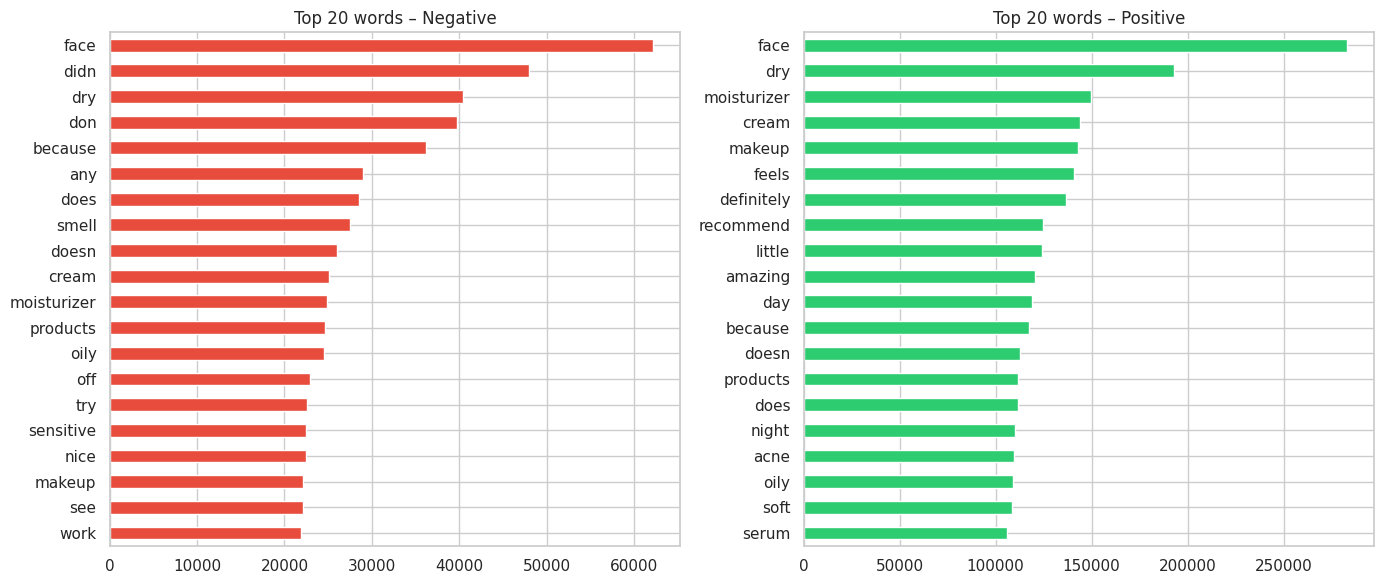

In [27]:
STOP = {
    'the','a','an','and','or','but','in','on','at','to','for','of','with',
    'is','it','its','was','are','be','been','have','has','had','do','did',
    'this','that','these','those','i','me','my','we','you','your','he','she',
    'they','them','their','so','not','just','very','can','would','will','get',
    'got','use','used','using','also','as','from','if','no','up','out','more',
    'than','what','all','one','when','which','there','after','about','how',
    'like','some','into','only','other','over','even','product','really',
    'well','much','too','now','then','made','make','still','love','great',
    'good','since','back','skin','feel','time'
}

def top_words(texts: pd.Series, n: int = 20) -> list:
    words = re.findall(r"[a-z]+", ' '.join(texts.fillna('').str.lower()))
    return Counter(
        w for w in words if w not in STOP and len(w) > 2
    ).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (cls, label) in zip(axes, CLASS_LABELS.items()):
    subset = df[df[TARGET] == cls]['review_text']
    words, freqs = zip(*top_words(subset, 20))
    pd.Series(freqs, index=words).plot(kind='barh', ax=ax, color=COLORS[cls])
    ax.set_title(f'Top 20 words – {label}')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Text Characteristics

In [28]:
display(
    df.groupby(TARGET)['review_text_length']
      .describe()[['mean','50%','max']]
      .rename(index=CLASS_LABELS)
      .round(0)
)

,mean,50%,max
LABEL-rating-category,,,
Negative,318.0,261.0,4990.0
Positive,321.0,263.0,6448.0


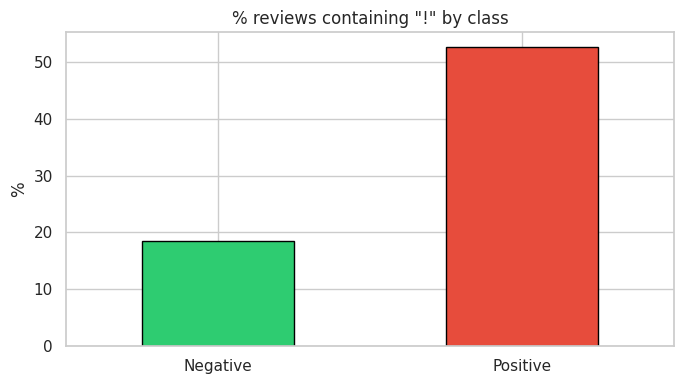

In [29]:
excl = df.groupby(TARGET)['has_exclamation'].mean() * 100
excl.index = [CLASS_LABELS[k] for k in excl.index]
excl.plot(kind='bar', color=[COLORS[k] for k in df[TARGET].unique() if k in COLORS],
          edgecolor='black', figsize=(7, 4))
plt.title('% reviews containing "!" by class')
plt.ylabel('%')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Extra Q1: Do popular products receive better reviews?

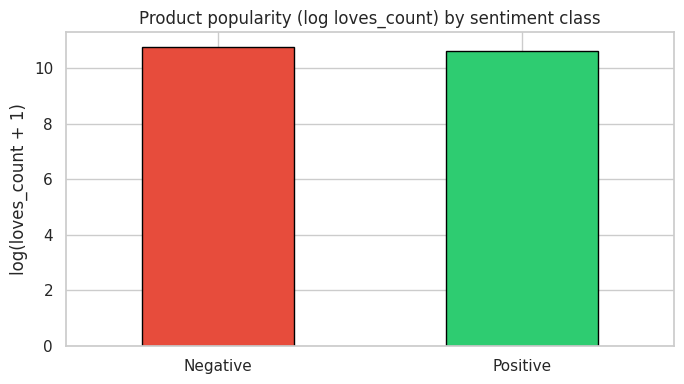

In [30]:
df['loves_log'] = np.log1p(df['loves_count'])
loves_by_class = df.groupby(TARGET)['loves_log'].mean()
loves_by_class.index = [CLASS_LABELS[k] for k in loves_by_class.index]

loves_by_class.plot(kind='bar',
                    color=[COLORS[0.0], COLORS[1.0]],
                    edgecolor='black', figsize=(7, 4))
plt.title('Product popularity (log loves_count) by sentiment class')
plt.ylabel('log(loves_count + 1)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Extra Q2: Does price affect sentiment?

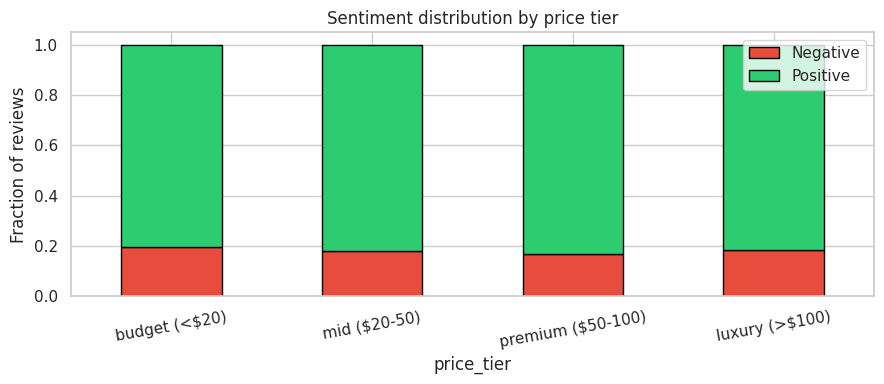

In [31]:
df['price_tier'] = pd.cut(df['price_usd'],
                          bins=[0, 20, 50, 100, 10000],
                          labels=['budget (<$20)', 'mid ($20-50)',
                                  'premium ($50-100)', 'luxury (>$100)'])

price_sent = (df.groupby('price_tier')[TARGET]
                .value_counts(normalize=True)
                .unstack()
                .fillna(0)
                .rename(columns=CLASS_LABELS))
price_sent.plot(kind='bar', stacked=True,
               color=[COLORS[0.0], COLORS[1.0]],
               edgecolor='black', figsize=(9, 4))
plt.title('Sentiment distribution by price tier')
plt.ylabel('Fraction of reviews')
plt.xticks(rotation=10)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 12. Summary & Recommendations

**Dataset:** 1,093,845 reviews, 37 columns.

**Target:** Categorical (3 classes). Strong class imbalance – class 2 (positive) dominates (~82%). Recommendation: use `class_weight='balanced'` and F1-macro as the metric.

**Missing values:**
- Demographic features (`skin_tone`, `eye_color`, `skin_type`, `hair_color`): 40–60% missing → fill with `'unknown'` or drop
- `sale_price_usd`, `value_price_usd`: high % missing → replace with binary `is_discounted`
- `price_vs_value_ratio`: missing when `value_price_usd` is absent → fill with `1.0`

**Sparse rows:** Most rows are missing only demographic columns (4–5 fields). Very few rows have >10 missing values — dropping them is safe.

**Correlations:**
- No strong numerical correlations with the target (max ~0.15)
- `price_usd`, `value_price_usd`, `child_max/min_price`: high inter-correlation → remove redundant columns

**Text:**
- Primary signal for sentiment is in `review_text` — words clearly differentiate classes
- Negative reviews are longer (detailed complaints); positive reviews are shorter
- Negation tokens (`NOT_good`, `NOT_work`) appear prominently in the negative class
- Positive reviews contain `!` more often than negative ones

**Recommendations:**
1. Main feature: vectorize `review_text` with BoW/TF-IDF (highest signal)
2. Use `class_weight='balanced'` in all models
3. Fill demographic NaNs with `'unknown'`, encode as categorical
4. Drop highly correlated price columns (keep `price_usd` only)
5. Metric: F1-macro